### Объединение Comtrade и спаршенных данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
comtrade = pd.read_excel('data/comtrade_final.xlsx')
main = pd.read_excel('data/main_data.xlsx')

comtrade['hs'] = comtrade['hs'].astype(str)
main['hs'] = main['hs'].astype(str)

Разберемся со странами на дополнение

In [3]:
japan_comtrade = comtrade[comtrade['country'] == 'Japan']
japan_main = main[main['country'] == 'Japan']
japan_comtrade_plot = japan_comtrade.groupby('rep_date', as_index=False)['value'].sum()
japan_main_plot = japan_main.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

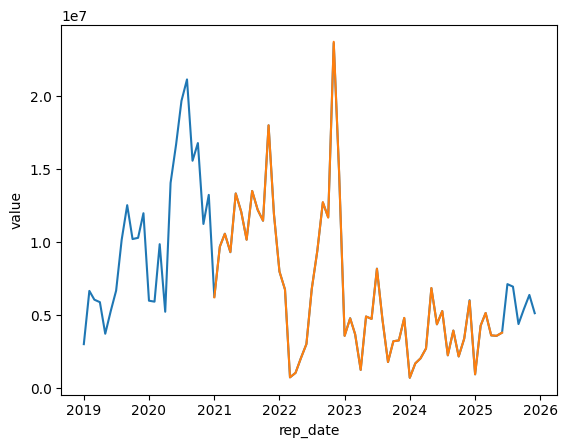

In [4]:
sns.lineplot(x=japan_comtrade_plot['rep_date'], y=japan_comtrade_plot['value'])
sns.lineplot(x=japan_main_plot['rep_date'], y=japan_main_plot['value'])

Данные совпадают. Вставляем за 2019-2020 в основу

In [5]:
main = pd.concat([japan_comtrade[japan_comtrade['rep_date'] < '2021-01-01'], main])

Разбираемся с Казахстаном

In [6]:
kaz_comtrade = comtrade[comtrade['country'] == 'Kazakhstan']
kaz_main = main[main['country'] == 'Kazakhstan']
kaz_comtrade_plot = kaz_comtrade.groupby('rep_date', as_index=False)['value'].sum()
kaz_main_plot = kaz_main.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

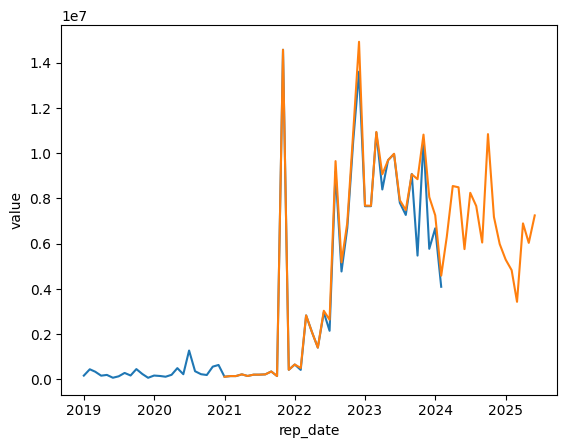

In [7]:
sns.lineplot(x=kaz_comtrade_plot['rep_date'], y=kaz_comtrade_plot['value'])
sns.lineplot(x=kaz_main_plot['rep_date'], y=kaz_main_plot['value'])

Данные совпадают. Вставляем за 2019-2020 в основу

In [8]:
main = pd.concat([kaz_comtrade[kaz_comtrade['rep_date'] < '2021-01-01'], main])

Остальные снизу обогащаем официальными данными ФТС

In [9]:
main.groupby('country', as_index=False)['rep_date'].min().sort_values(by='rep_date', ascending=False).head(15)

,country,rep_date
0,Albania,2022-06-01
33,Northern Ireland,2021-02-01
11,Ecuador,2020-12-01
32,North Macedonia,2020-06-01
20,Iceland,2020-03-01
8,Cyprus,2020-02-01
30,Montenegro,2019-04-01
3,Bosnia and Herzegovina,2019-02-01
36,Portugal,2019-02-01
39,Slovakia,2019-01-01


In [10]:
comtrade.groupby('country', as_index=False)['rep_date'].min().sort_values(by='rep_date', ascending=False).head(6)

,country,rep_date
12,Mauritius,2025-08-01
20,Uzbekistan,2019-11-01
4,Chile,2019-11-01
6,Indonesia,2019-10-01
10,Kyrgyzstan,2019-03-01
5,Egypt,2019-01-01


In [11]:
country_map = {
    'Узбекистан': 'Uzbekistan', 'Республика Молдова': 'Rep. of Moldova', 'Албания': 'Albania', 'Эквадор': 'Ecuador', 'Чили': 'Chile', 'Кыргызстан': 'Kyrgyzstan',
    'Кипр': 'Cyprus', 'Черногория': 'Montenegro', 'Португалия': 'Portugal', 'Босния и Герцеговина': 'Bosnia and Herzegovina', 'Индонезия': 'Indonesia'
}

import_2019 = pd.read_excel("./data/historical_data_import.xlsx", sheet_name="queries_output")
import_2019 = import_2019.drop(columns="STRANA")
import_2019 = import_2019[import_2019["Страна"] != 0]
import_2019["TNVED"] = import_2019["TNVED"].astype(str).str.zfill(4)
import_2019 = pd.melt(import_2019, id_vars=["TNVED", "Страна"])
import_2019 = import_2019.rename(columns={"Страна": "country", "variable": "rep_date", "TNVED": "hs"})
import_2019["rep_date"] = pd.to_datetime(import_2019["rep_date"], format="%d.%m.%Y")
import_2019 = import_2019[import_2019['country'].isin(['Узбекистан', 'Республика Молдова', 'Чили', 'Кыргызстан', 'Индонезия',
                                                       'Албания', 'Эквадор', 'Кипр', 'Черногория', 'Португалия', 'Босния и Герцеговина'])]
import_2019 = import_2019[import_2019['hs'].isin(['9018', '9019', '9020', '9021', '9022', '9025', '9027', '9030', '9031'])]
import_2019['country'] = import_2019['country'].map(country_map)
import_2019

,hs,country,rep_date,value
44478,9018,Uzbekistan,2019-01-01,0
44482,9018,Portugal,2019-01-01,0
44484,9018,Indonesia,2019-01-01,58165
44494,9018,Cyprus,2019-01-01,0
44504,9018,Kyrgyzstan,2019-01-01,42939
...,...,...,...,...
1731633,9031,Kyrgyzstan,2021-12-01,3911
1731639,9031,Indonesia,2021-12-01,95698
1731648,9031,Bosnia and Herzegovina,2021-12-01,0
1731667,9031,Uzbekistan,2021-12-01,0


Узбекистан

In [12]:
uz_comtrade = comtrade[comtrade['country'] == 'Uzbekistan']
uz_comtrade_plot = uz_comtrade.groupby('rep_date', as_index=False)['value'].sum()
uz_fts = import_2019[import_2019['country'] == 'Uzbekistan']
uz_fts_plot = uz_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

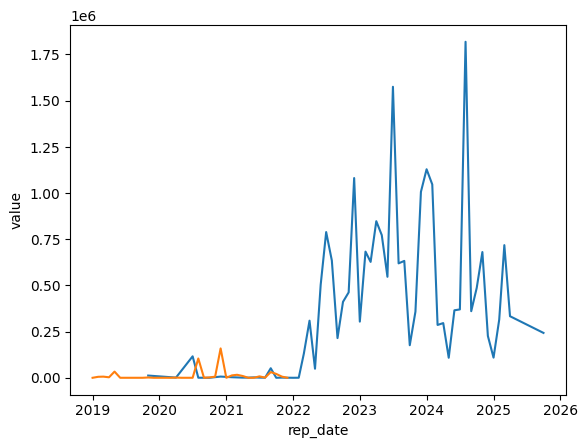

In [13]:
sns.lineplot(x=uz_comtrade_plot['rep_date'], y=uz_comtrade_plot['value'])
sns.lineplot(x=uz_fts_plot['rep_date'], y=uz_fts_plot['value'])

In [14]:
comtrade = pd.concat([comtrade, uz_fts[uz_fts['rep_date'] < '2019-11-01']])

Молдова

In [15]:
mol_comtrade = comtrade[comtrade['country'] == 'Rep. of Moldova']
mol_comtrade_plot = mol_comtrade.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Rep. of Moldova']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

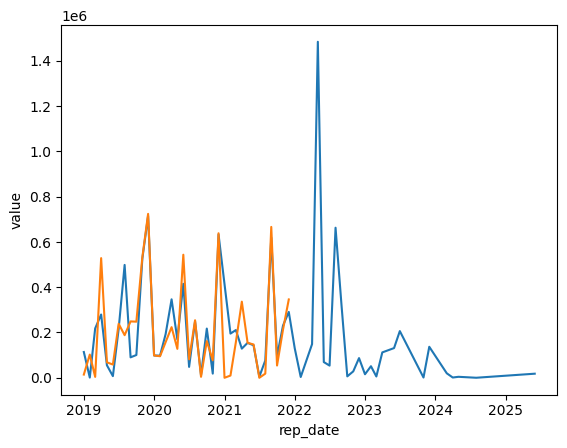

In [16]:
sns.lineplot(x=mol_comtrade_plot['rep_date'], y=mol_comtrade_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

Чили

In [17]:
ch_comtrade = comtrade[comtrade['country'] == 'Chile']
ch_comtrade_plot = ch_comtrade.groupby('rep_date', as_index=False)['value'].sum()
ch_fts = import_2019[import_2019['country'] == 'Chile']
ch_fts_plot = ch_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

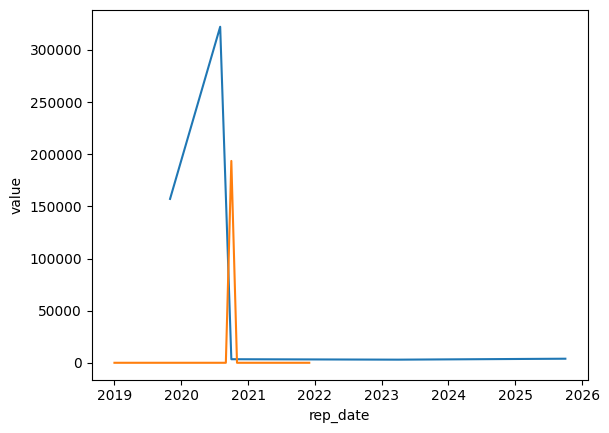

In [18]:
sns.lineplot(x=ch_comtrade_plot['rep_date'], y=ch_comtrade_plot['value'])
sns.lineplot(x=ch_fts_plot['rep_date'], y=ch_fts_plot['value'])

Индонезия

In [19]:
ind_comtrade = comtrade[comtrade['country'] == 'Indonesia']
ind_comtrade_plot = ind_comtrade.groupby('rep_date', as_index=False)['value'].sum()
ind_fts = import_2019[import_2019['country'] == 'Indonesia']
ind_fts_plot = ind_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

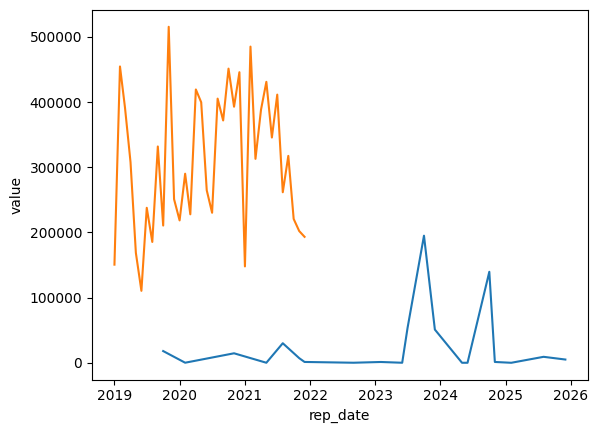

In [20]:
sns.lineplot(x=ind_comtrade_plot['rep_date'], y=ind_comtrade_plot['value'])
sns.lineplot(x=ind_fts_plot['rep_date'], y=ind_fts_plot['value'])

Траектории не совпадают, не будем брать

Киргизия

In [21]:
kg_comtrade = comtrade[comtrade['country'] == 'Kyrgyzstan']
kg_comtrade_plot = kg_comtrade.groupby('rep_date', as_index=False)['value'].sum()
kg_fts = import_2019[import_2019['country'] == 'Kyrgyzstan']
kg_fts_plot = kg_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

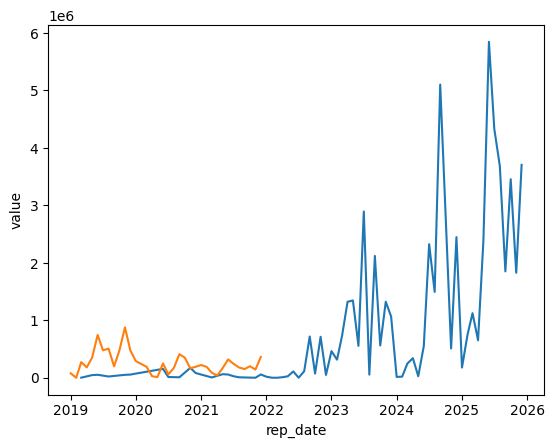

In [22]:
sns.lineplot(x=kg_comtrade_plot['rep_date'], y=kg_comtrade_plot['value'])
sns.lineplot(x=kg_fts_plot['rep_date'], y=kg_fts_plot['value'])

In [23]:
comtrade = pd.concat([comtrade, kg_fts[kg_fts['rep_date'] < '2019-03-01']])

Албания

In [24]:
mol_main = main[main['country'] == 'Albania']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Albania']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

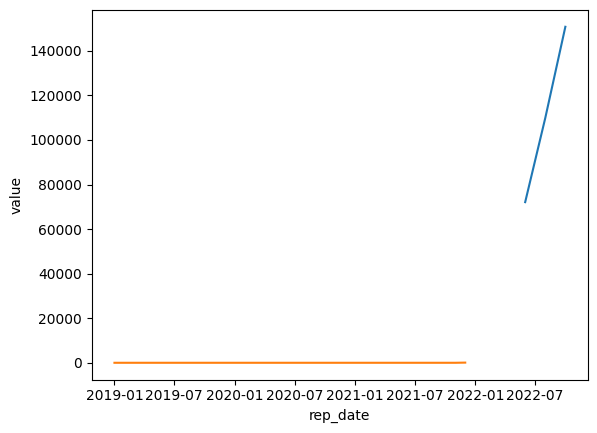

In [25]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

Эквадор

In [26]:
mol_main = main[main['country'] == 'Ecuador']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Ecuador']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

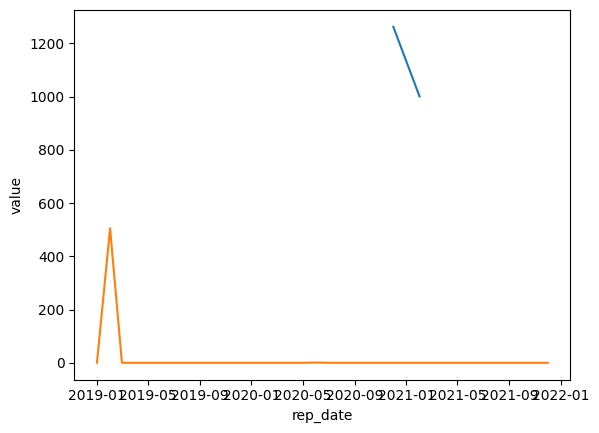

In [27]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

In [28]:
main = pd.concat([main, mol_fts[mol_fts['rep_date'] <= '2019-05-01']])

Кипр

In [29]:
mol_main = main[main['country'] == 'Cyprus']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Cyprus']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

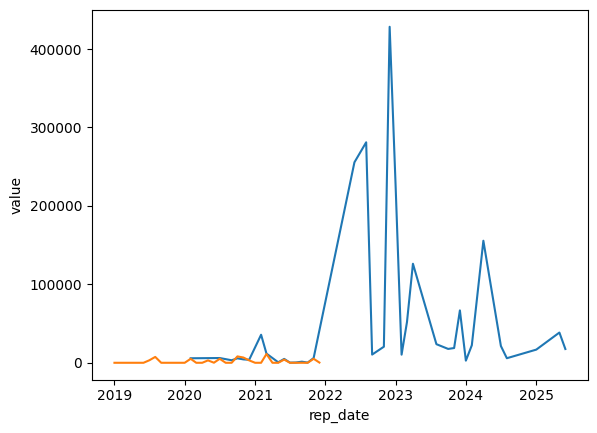

In [30]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

In [31]:
main = pd.concat([main, mol_fts[mol_fts['rep_date'] <= '2020-01-01']])

Черногория

In [32]:
mol_main = main[main['country'] == 'Montenegro']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Montenegro']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

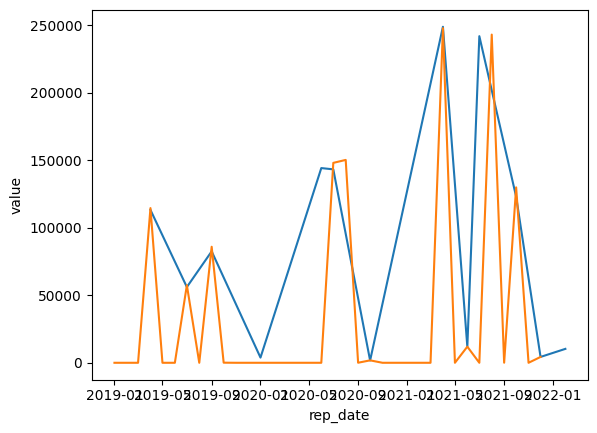

In [33]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

Португалия

In [34]:
mol_main = main[main['country'] == 'Portugal']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Portugal']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

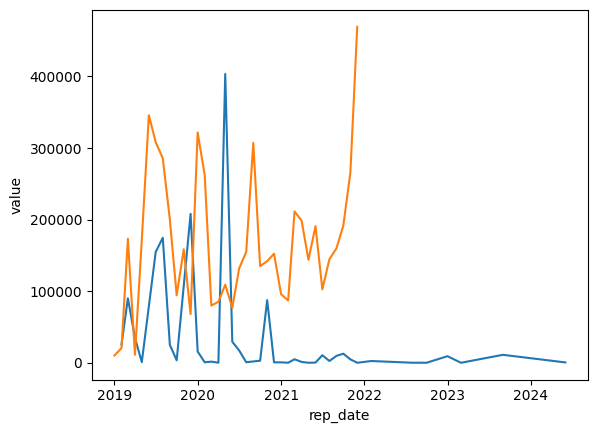

In [35]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

Босния и Герцеговина

In [36]:
mol_main = main[main['country'] == 'Bosnia and Herzegovina']
mol_main_plot = mol_main.groupby('rep_date', as_index=False)['value'].sum()
mol_fts = import_2019[import_2019['country'] == 'Bosnia and Herzegovina']
mol_fts_plot = mol_fts.groupby('rep_date', as_index=False)['value'].sum()

<Axes: xlabel='rep_date', ylabel='value'>

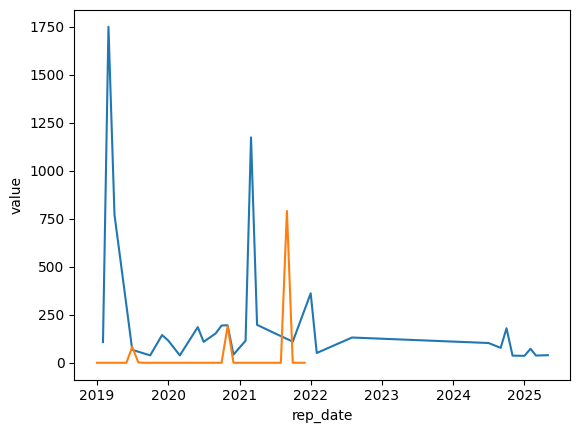

In [37]:
sns.lineplot(x=mol_main_plot['rep_date'], y=mol_main_plot['value'])
sns.lineplot(x=mol_fts_plot['rep_date'], y=mol_fts_plot['value'])

Соединяем источники

In [38]:
comtrade = comtrade[~comtrade['country'].isin(['Kazakhstan', 'Japan', 'Mauritius'])]

In [39]:
main = pd.concat([main, comtrade])
main

,rep_date,country,hs,value
30,2019-01-01,Kazakhstan,9018,106614.00
31,2019-01-01,Kazakhstan,9019,4836.46
32,2019-01-01,Kazakhstan,9020,5041.89
33,2019-01-01,Kazakhstan,9025,1578.35
34,2019-01-01,Kazakhstan,9027,30514.50
...,...,...,...,...
92910,2019-02-01,Kyrgyzstan,9022,0.00
93060,2019-02-01,Kyrgyzstan,9025,0.00
93248,2019-02-01,Kyrgyzstan,9027,0.00
93483,2019-02-01,Kyrgyzstan,9030,0.00


Заполним пропуски ноликом

In [40]:
# создаем все возможные значения
all_dates = pd.date_range(start='2019-01-01', end='2025-06-01', freq='MS').to_numpy()
all_countries = main['country'].unique()
all_hs = main['hs'].unique()

# создаем полную сетку
full_index = pd.MultiIndex.from_product(
    [all_dates, all_countries, all_hs],
    names=['rep_date', 'country', 'hs']
)

# приводим к этому индексу
main = (
    main.set_index(['rep_date', 'country', 'hs'])
      .reindex(full_index, fill_value=0)
      .reset_index()
)

Сортируем и отрезаем даты

In [41]:
main = main[(main['rep_date'] >= '2019-01-01') & (main['rep_date'] <= '2025-06-01')]
main = main.sort_values(by=['rep_date', 'country', 'hs'])
main

,rep_date,country,hs,value
450,2019-01-01,Albania,9018,0.0
451,2019-01-01,Albania,9019,0.0
452,2019-01-01,Albania,9020,0.0
458,2019-01-01,Albania,9021,0.0
457,2019-01-01,Albania,9022,0.0
...,...,...,...,...
48427,2025-06-01,Uzbekistan,9022,0.0
48423,2025-06-01,Uzbekistan,9025,0.0
48424,2025-06-01,Uzbekistan,9027,0.0
48425,2025-06-01,Uzbekistan,9030,0.0


In [42]:
duplicates = main[
    main.duplicated(
        subset=['rep_date', 'country', 'hs'],
        keep=False
    )
]

duplicates

,rep_date,country,hs,value


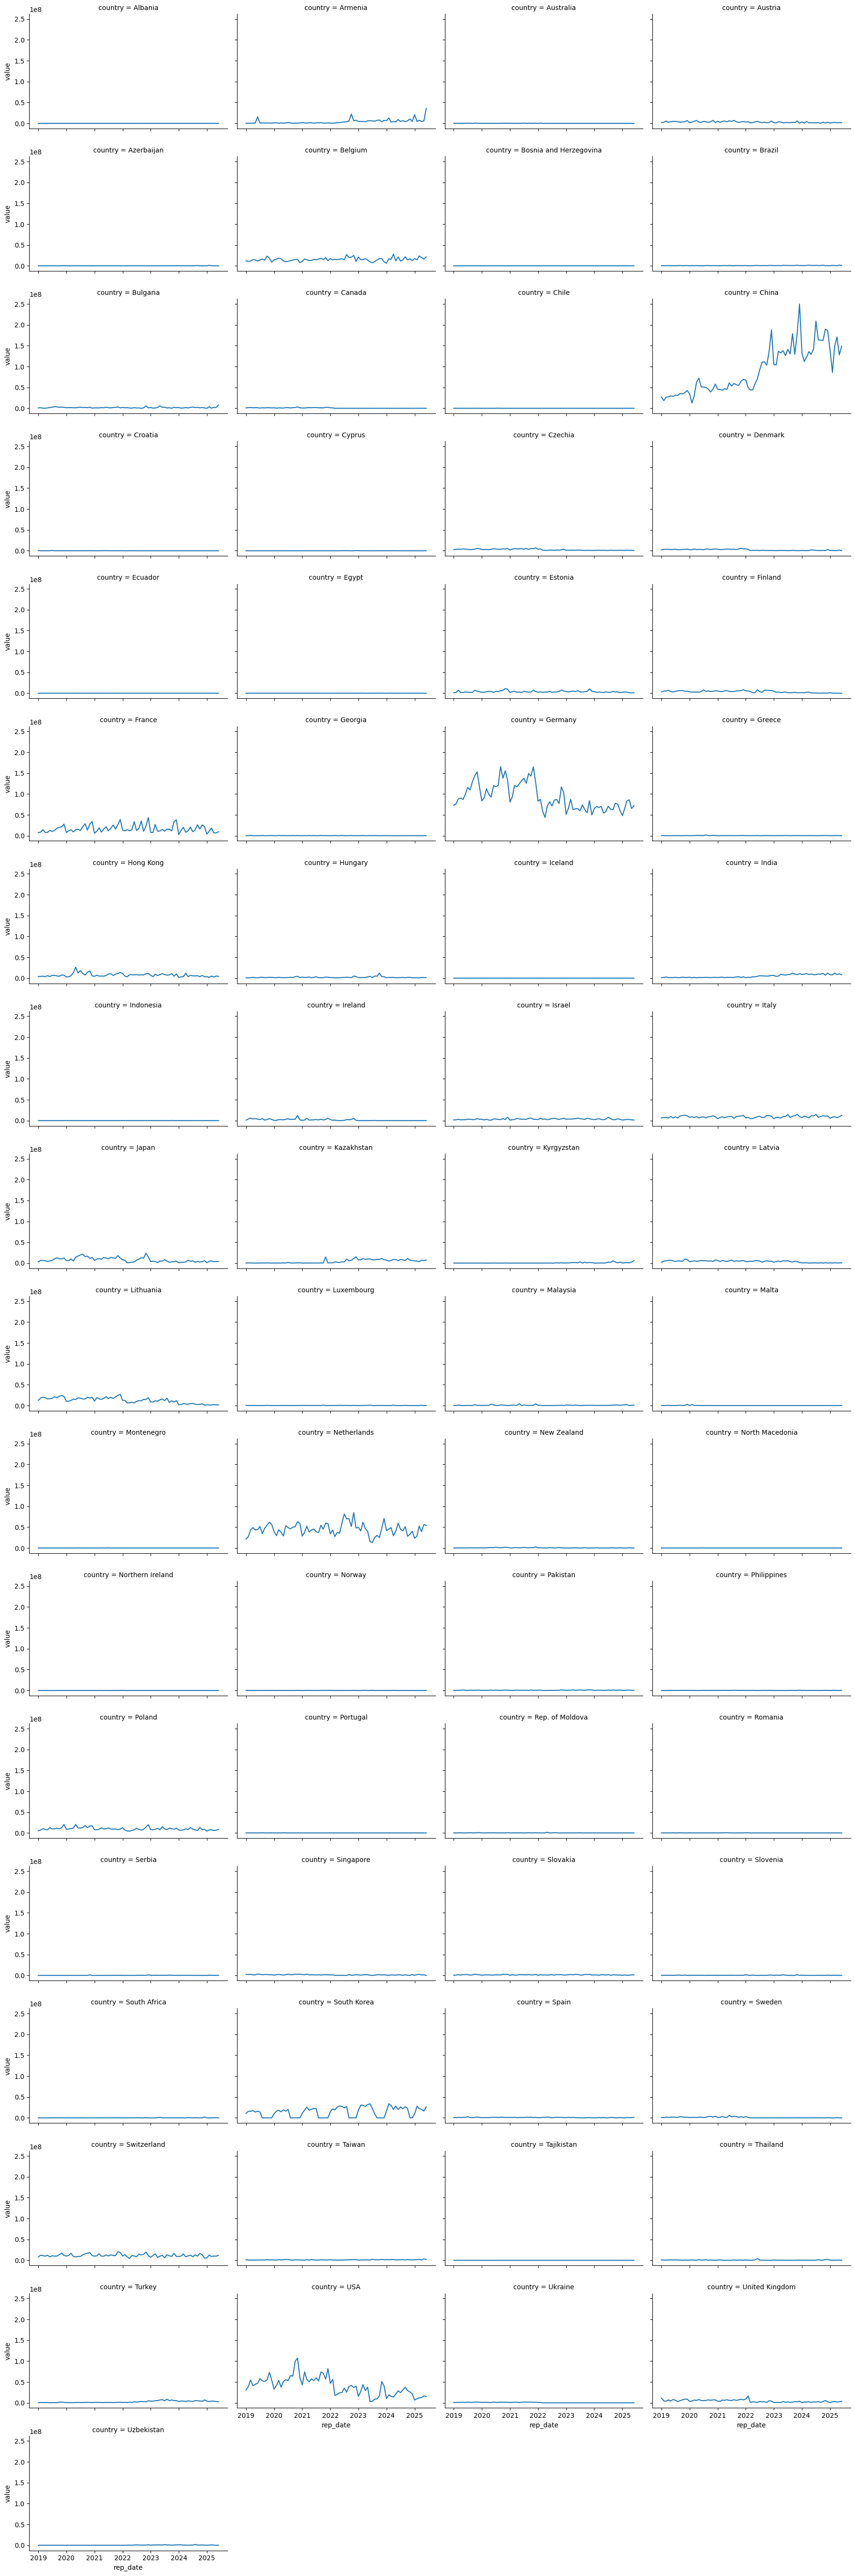

In [43]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
sns.relplot(
    data=series,
    x='rep_date',
    y='value',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

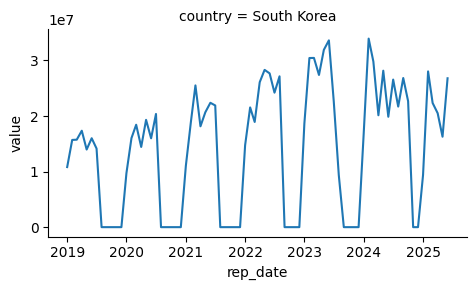

In [44]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
sns.relplot(
    data=series[series['country'] == 'South Korea'],
    x='rep_date',
    y='value',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

In [45]:
main.country.nunique()

69

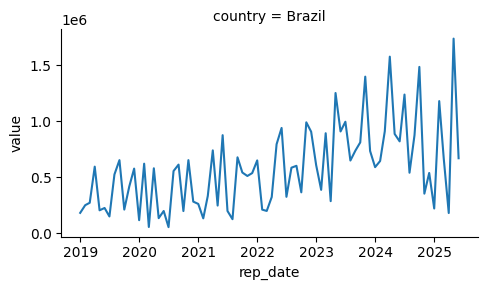

In [46]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
sns.relplot(
    data=series[series['country'] == 'Brazil'],
    x='rep_date',
    y='value',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

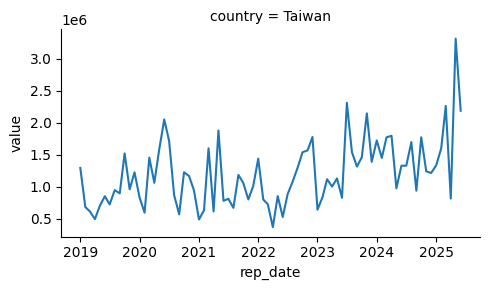

In [47]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
sns.relplot(
    data=series[series['country'] == 'Taiwan'],
    x='rep_date',
    y='value',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

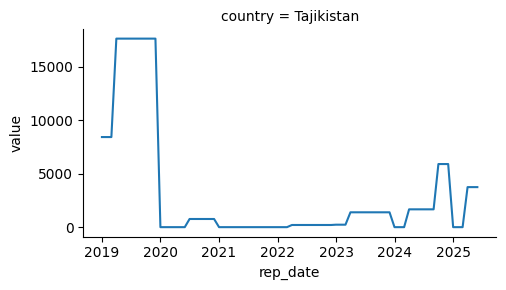

In [48]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
sns.relplot(
    data=series[series['country'] == 'Tajikistan'],
    x='rep_date',
    y='value',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

In [49]:
main.to_excel('data/full_main.xlsx', index=False)

In [50]:
main = pd.read_excel('data/full_main.xlsx')
main

,rep_date,country,hs,value
0,2019-01-01,Albania,9018,0.0
1,2019-01-01,Albania,9019,0.0
2,2019-01-01,Albania,9020,0.0
3,2019-01-01,Albania,9021,0.0
4,2019-01-01,Albania,9022,0.0
...,...,...,...,...
48433,2025-06-01,Uzbekistan,9022,0.0
48434,2025-06-01,Uzbekistan,9025,0.0
48435,2025-06-01,Uzbekistan,9027,0.0
48436,2025-06-01,Uzbekistan,9030,0.0


In [51]:
main.rep_date.nunique()

78

In [52]:
duplicates = main[
    main.duplicated(
        subset=['rep_date', 'country', 'hs'],
        keep=False
    )
]

duplicates

,rep_date,country,hs,value


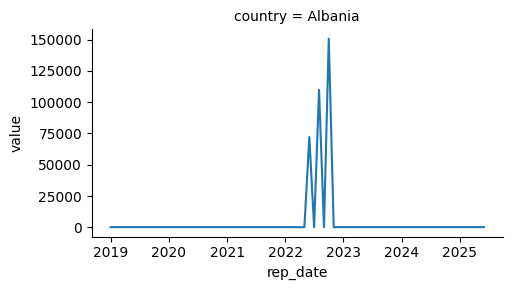

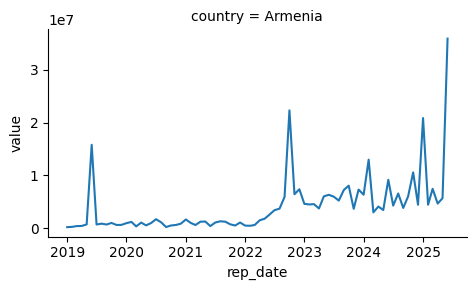

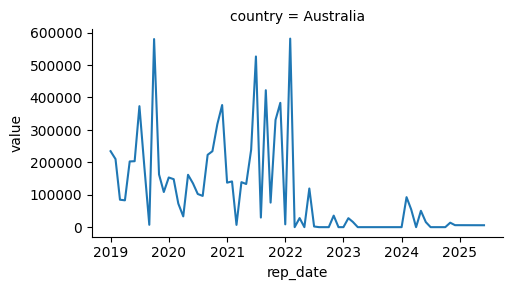

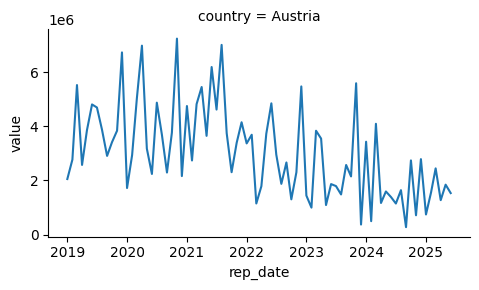

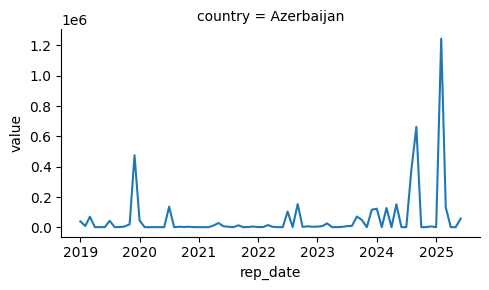

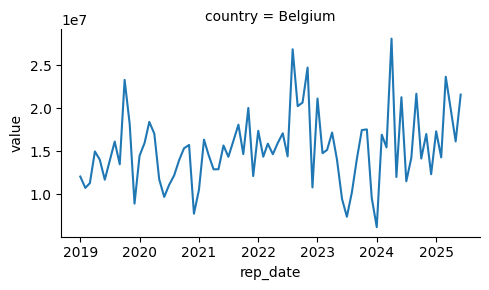

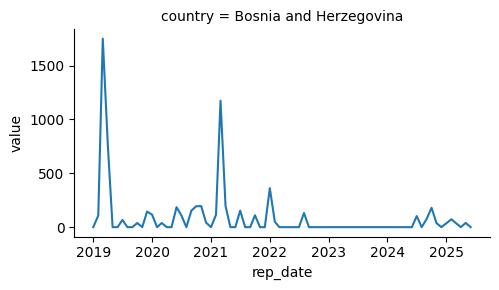

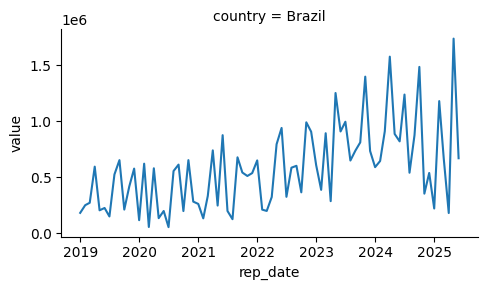

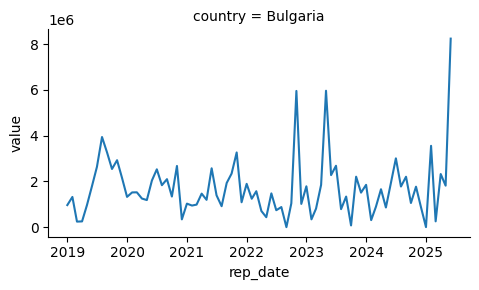

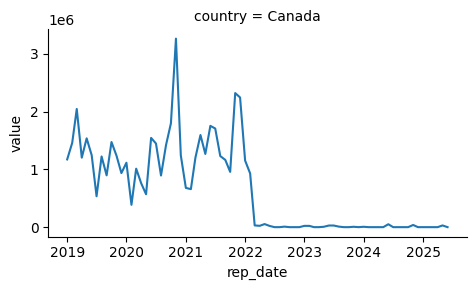

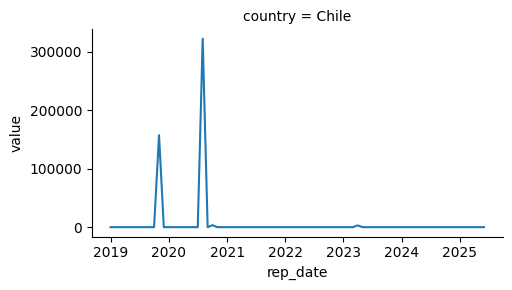

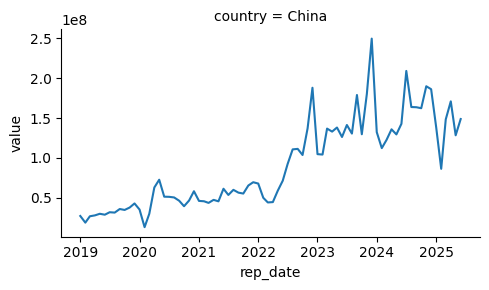

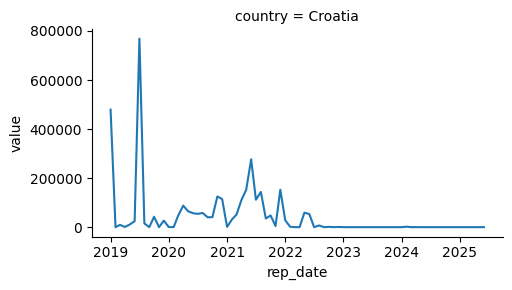

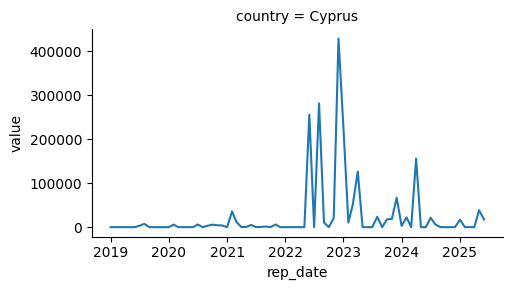

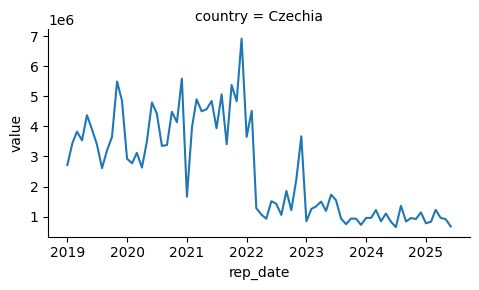

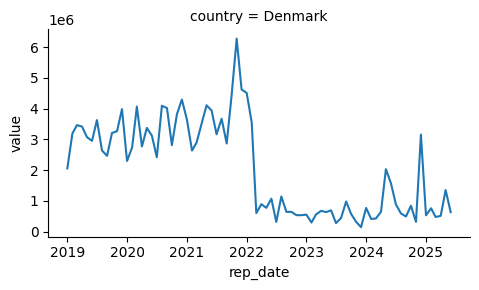

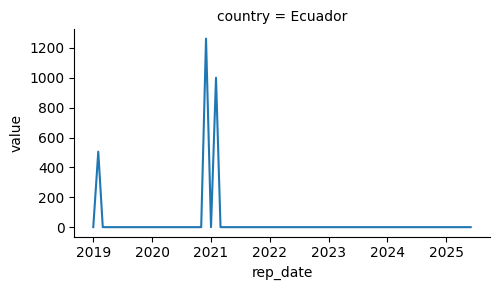

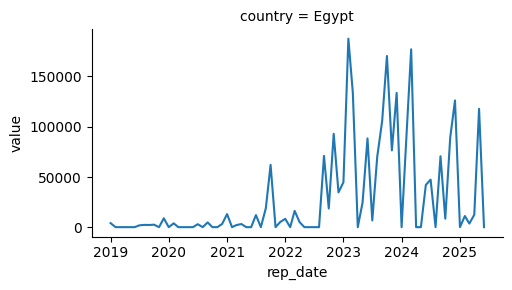

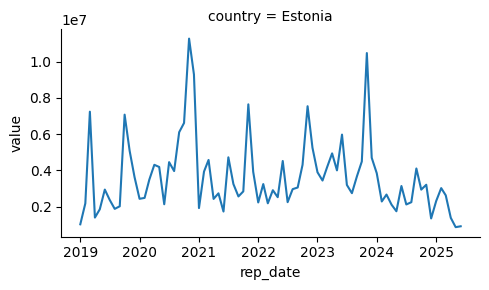

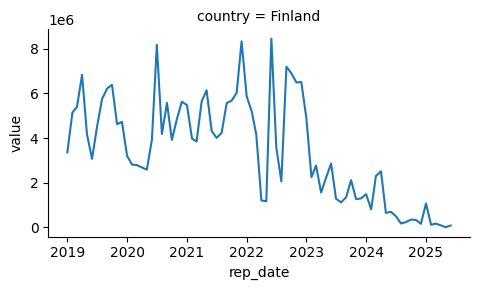

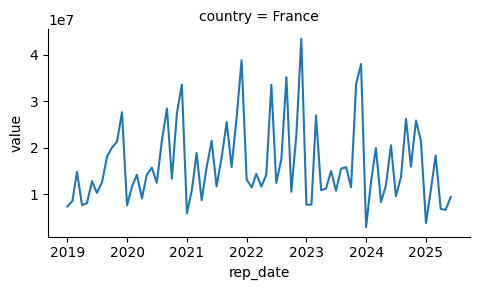

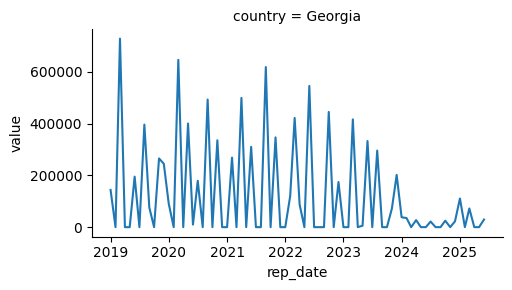

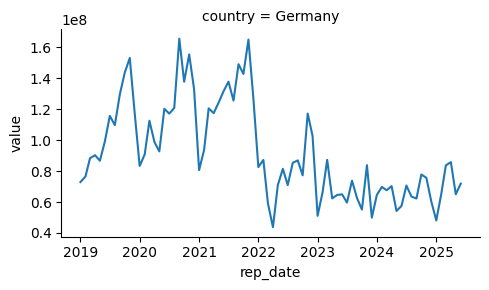

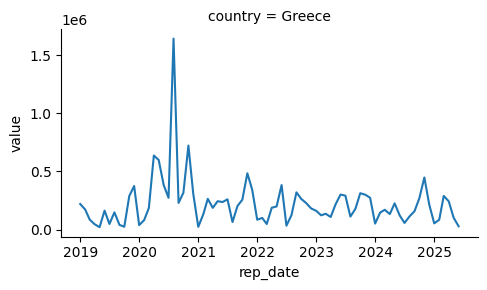

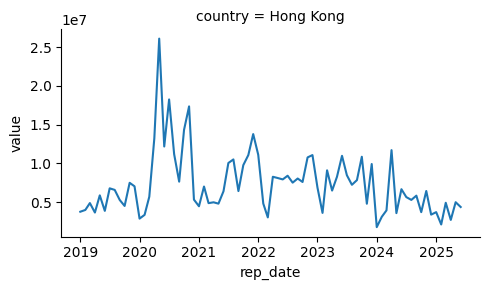

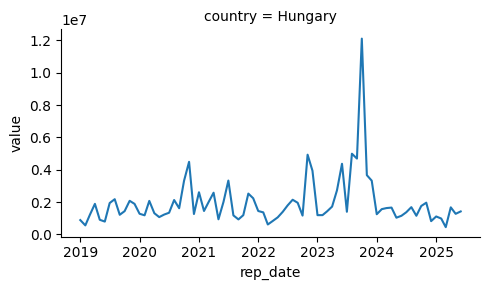

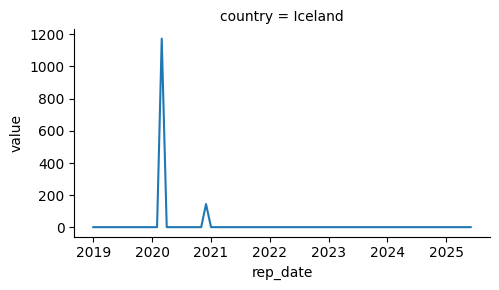

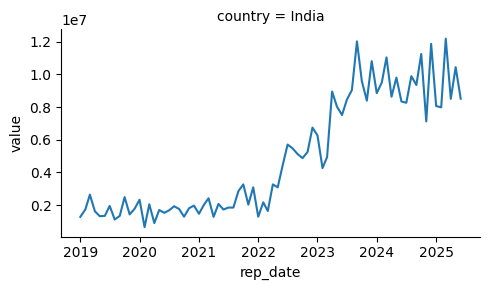

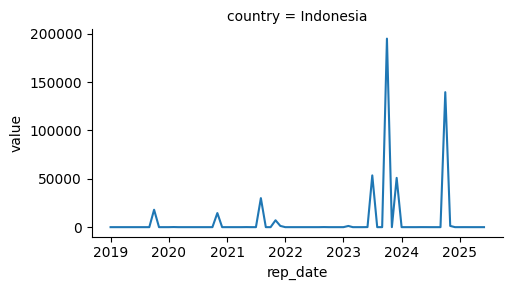

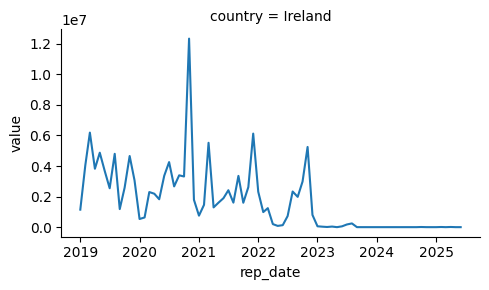

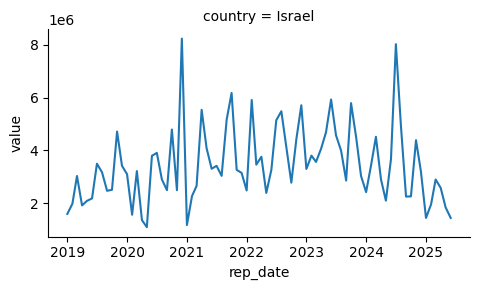

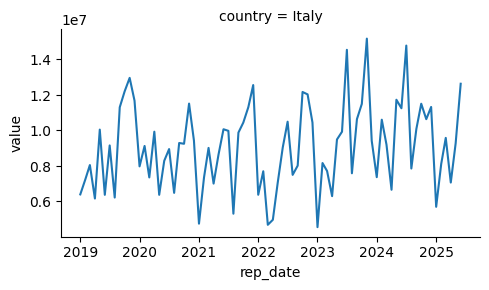

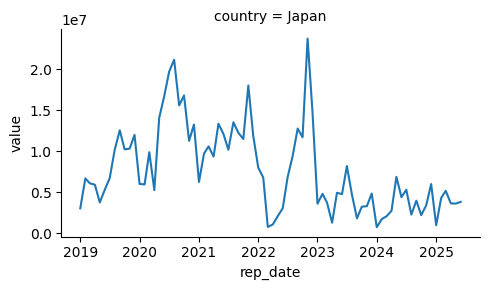

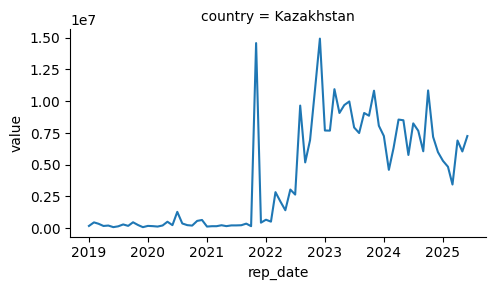

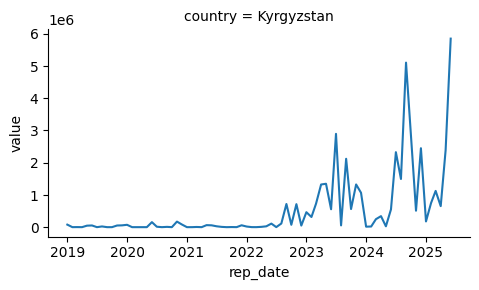

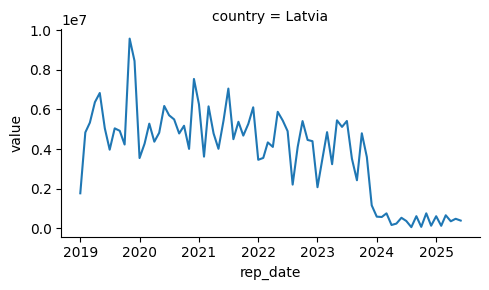

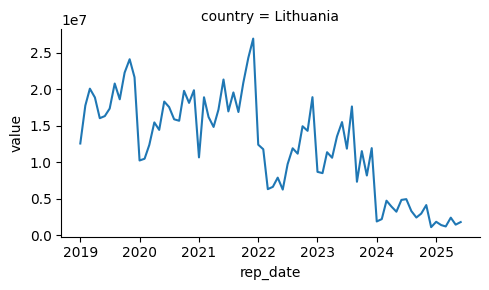

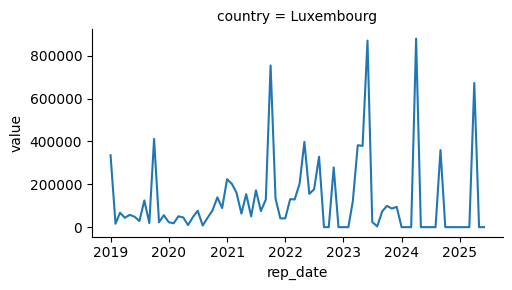

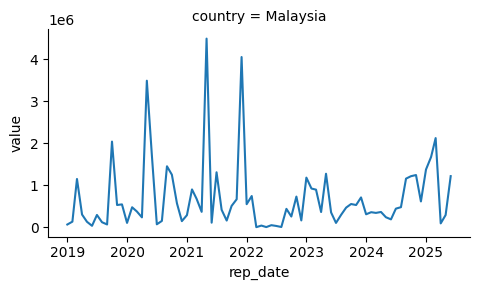

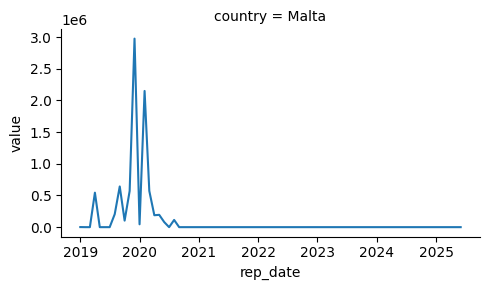

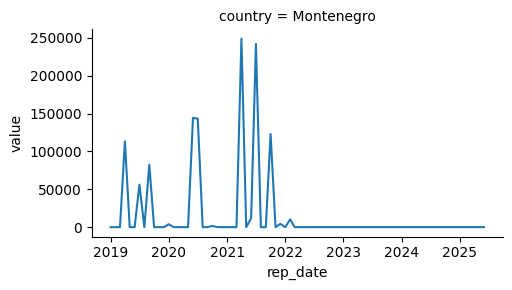

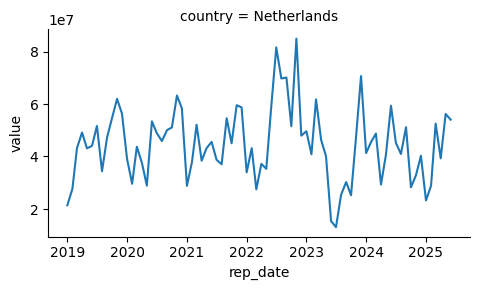

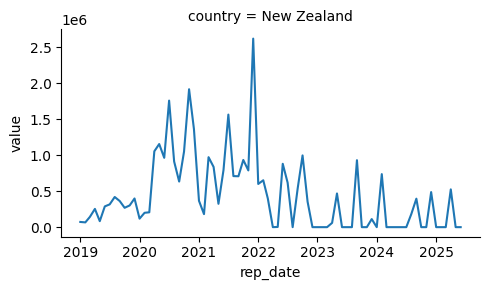

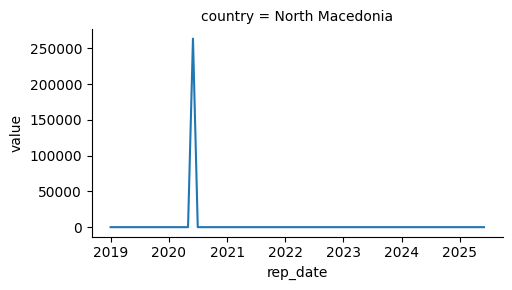

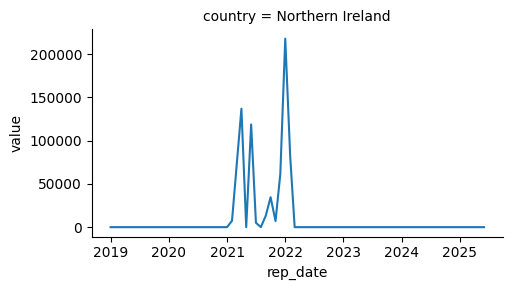

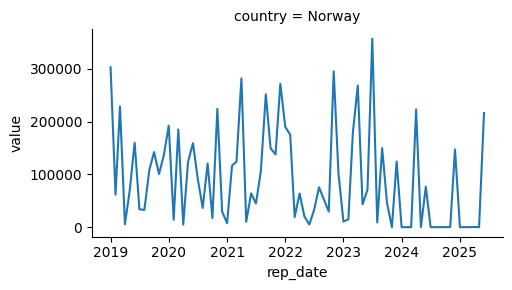

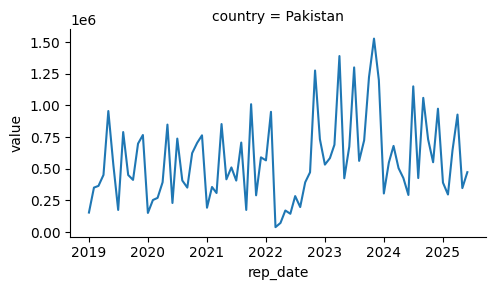

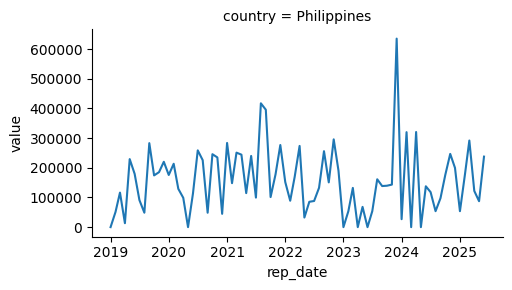

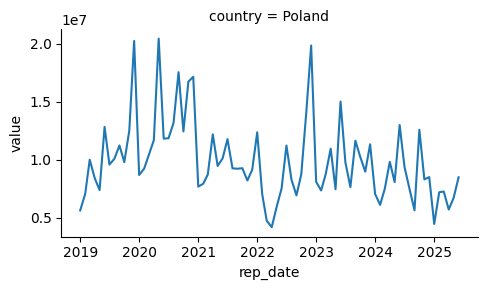

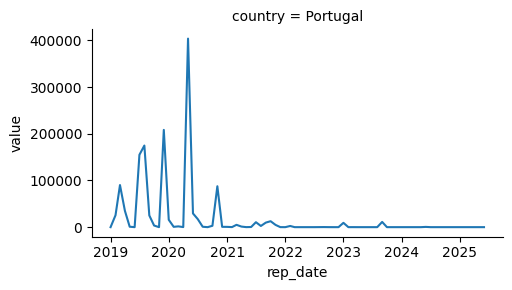

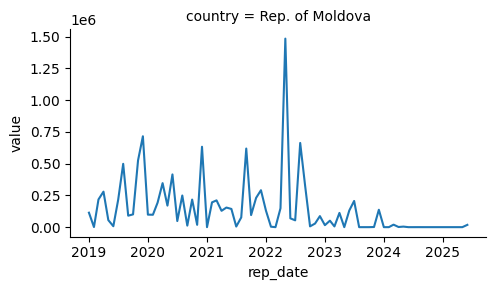

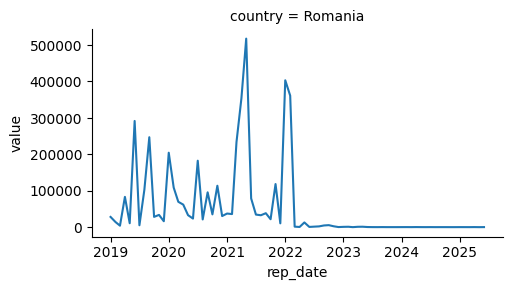

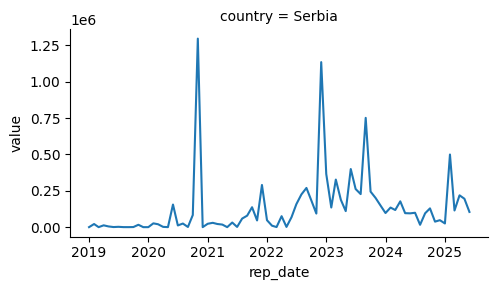

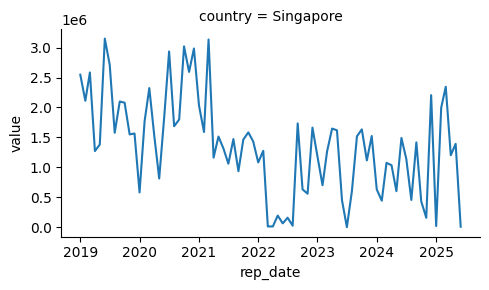

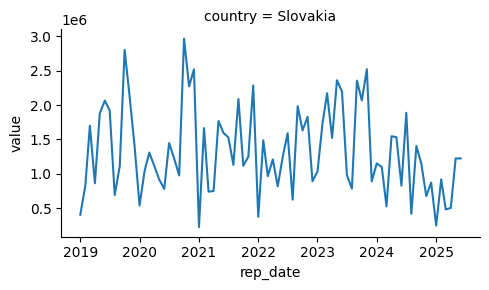

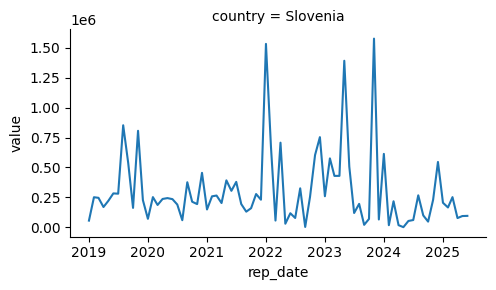

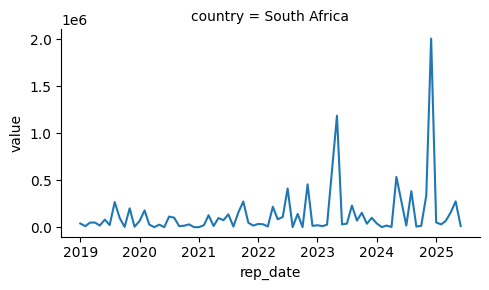

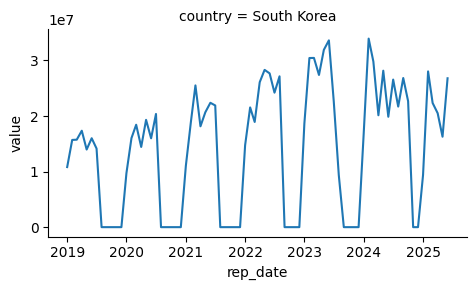

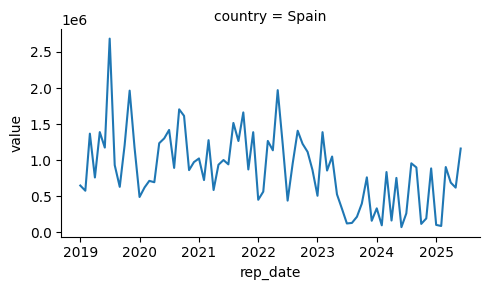

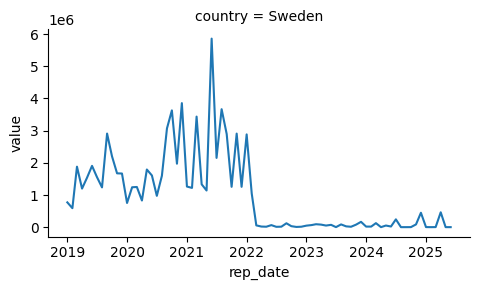

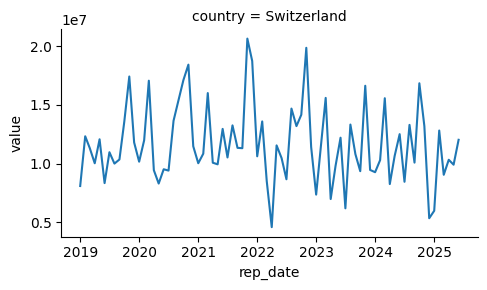

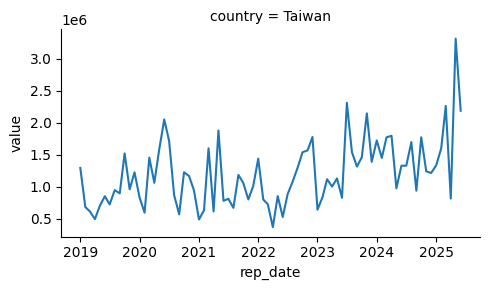

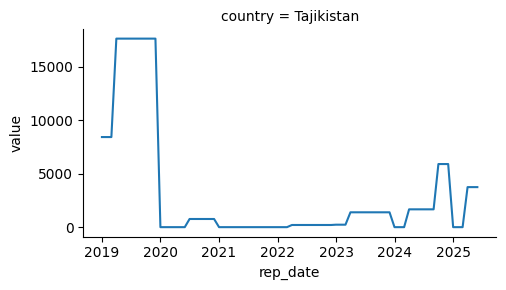

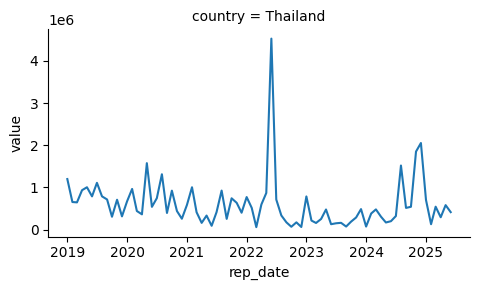

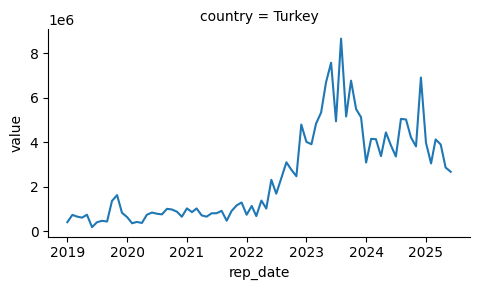

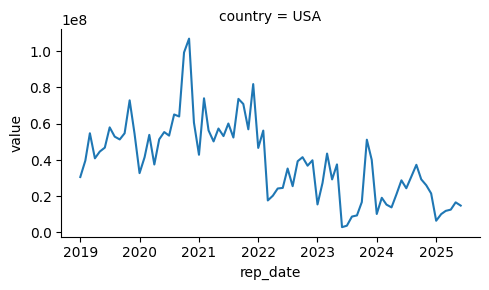

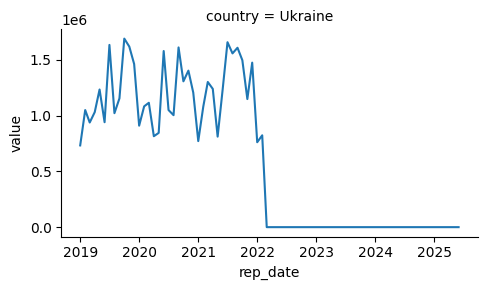

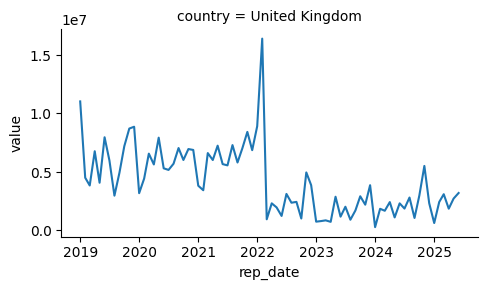

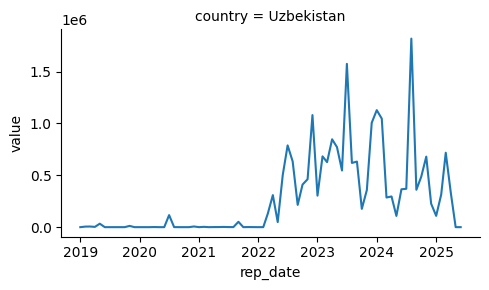

In [53]:
series = main.groupby(['country', 'rep_date'], as_index=False)['value'].sum()
for country in series['country'].unique():
    sns.relplot(
        data=series[series['country'] == country],
        x='rep_date',
        y='value',
        col='country',
        col_wrap=4,
        kind='line',
        height=3,
        aspect=1.5
    )
    plt.show()

In [1]:
import pandas as pd

pd.read_excel('data/full_main.xlsx')['country'].unique()

array(['Albania', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
       'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria',
       'Canada', 'Chile', 'China', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Ecuador', 'Egypt', 'Estonia', 'Finland', 'France',
       'Georgia', 'Germany', 'Greece', 'Hong Kong', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan',
       'Kazakhstan', 'Kyrgyzstan', 'Latvia', 'Lithuania', 'Luxembourg',
       'Malaysia', 'Malta', 'Montenegro', 'Netherlands', 'New Zealand',
       'North Macedonia', 'Northern Ireland', 'Norway', 'Pakistan',
       'Philippines', 'Poland', 'Portugal', 'Rep. of Moldova', 'Romania',
       'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa',
       'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan',
       'Tajikistan', 'Thailand', 'Turkey', 'USA', 'Ukraine',
       'United Kingdom', 'Uzbekistan'], dtype=object)